In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dataset=pd.read_csv("bank-full.csv",delimiter=";")
dataset.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
dataset.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [11]:
dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [12]:
dataset.shape

(45211, 17)

In [13]:
dataset["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

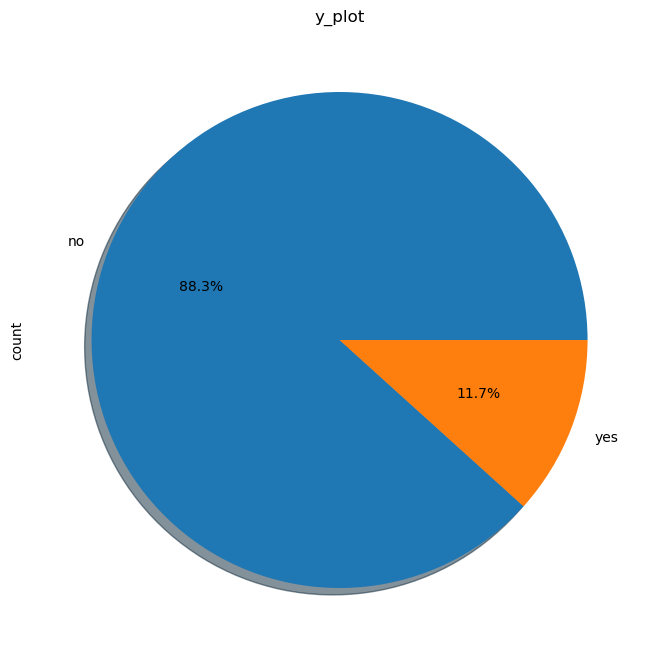

In [14]:
f,ax,=plt.subplots(figsize=(8,10))
ax=dataset['y'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',shadow=True)
ax.set_title('y_plot')
plt.show()

In [16]:
categoricals=[feature for feature in dataset.columns if dataset[feature].dtypes=='O']
categoricals

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [18]:
for feature in categorical_features:
    print("The feature {} has the number of categories : {}".format(feature,len(dataset[feature].unique())))

The feature job has the number of categories : 12
The feature marital has the number of categories : 3
The feature education has the number of categories : 4
The feature default has the number of categories : 2
The feature housing has the number of categories : 2
The feature loan has the number of categories : 2
The feature contact has the number of categories : 3
The feature month has the number of categories : 12
The feature poutcome has the number of categories : 4
The feature y has the number of categories : 2


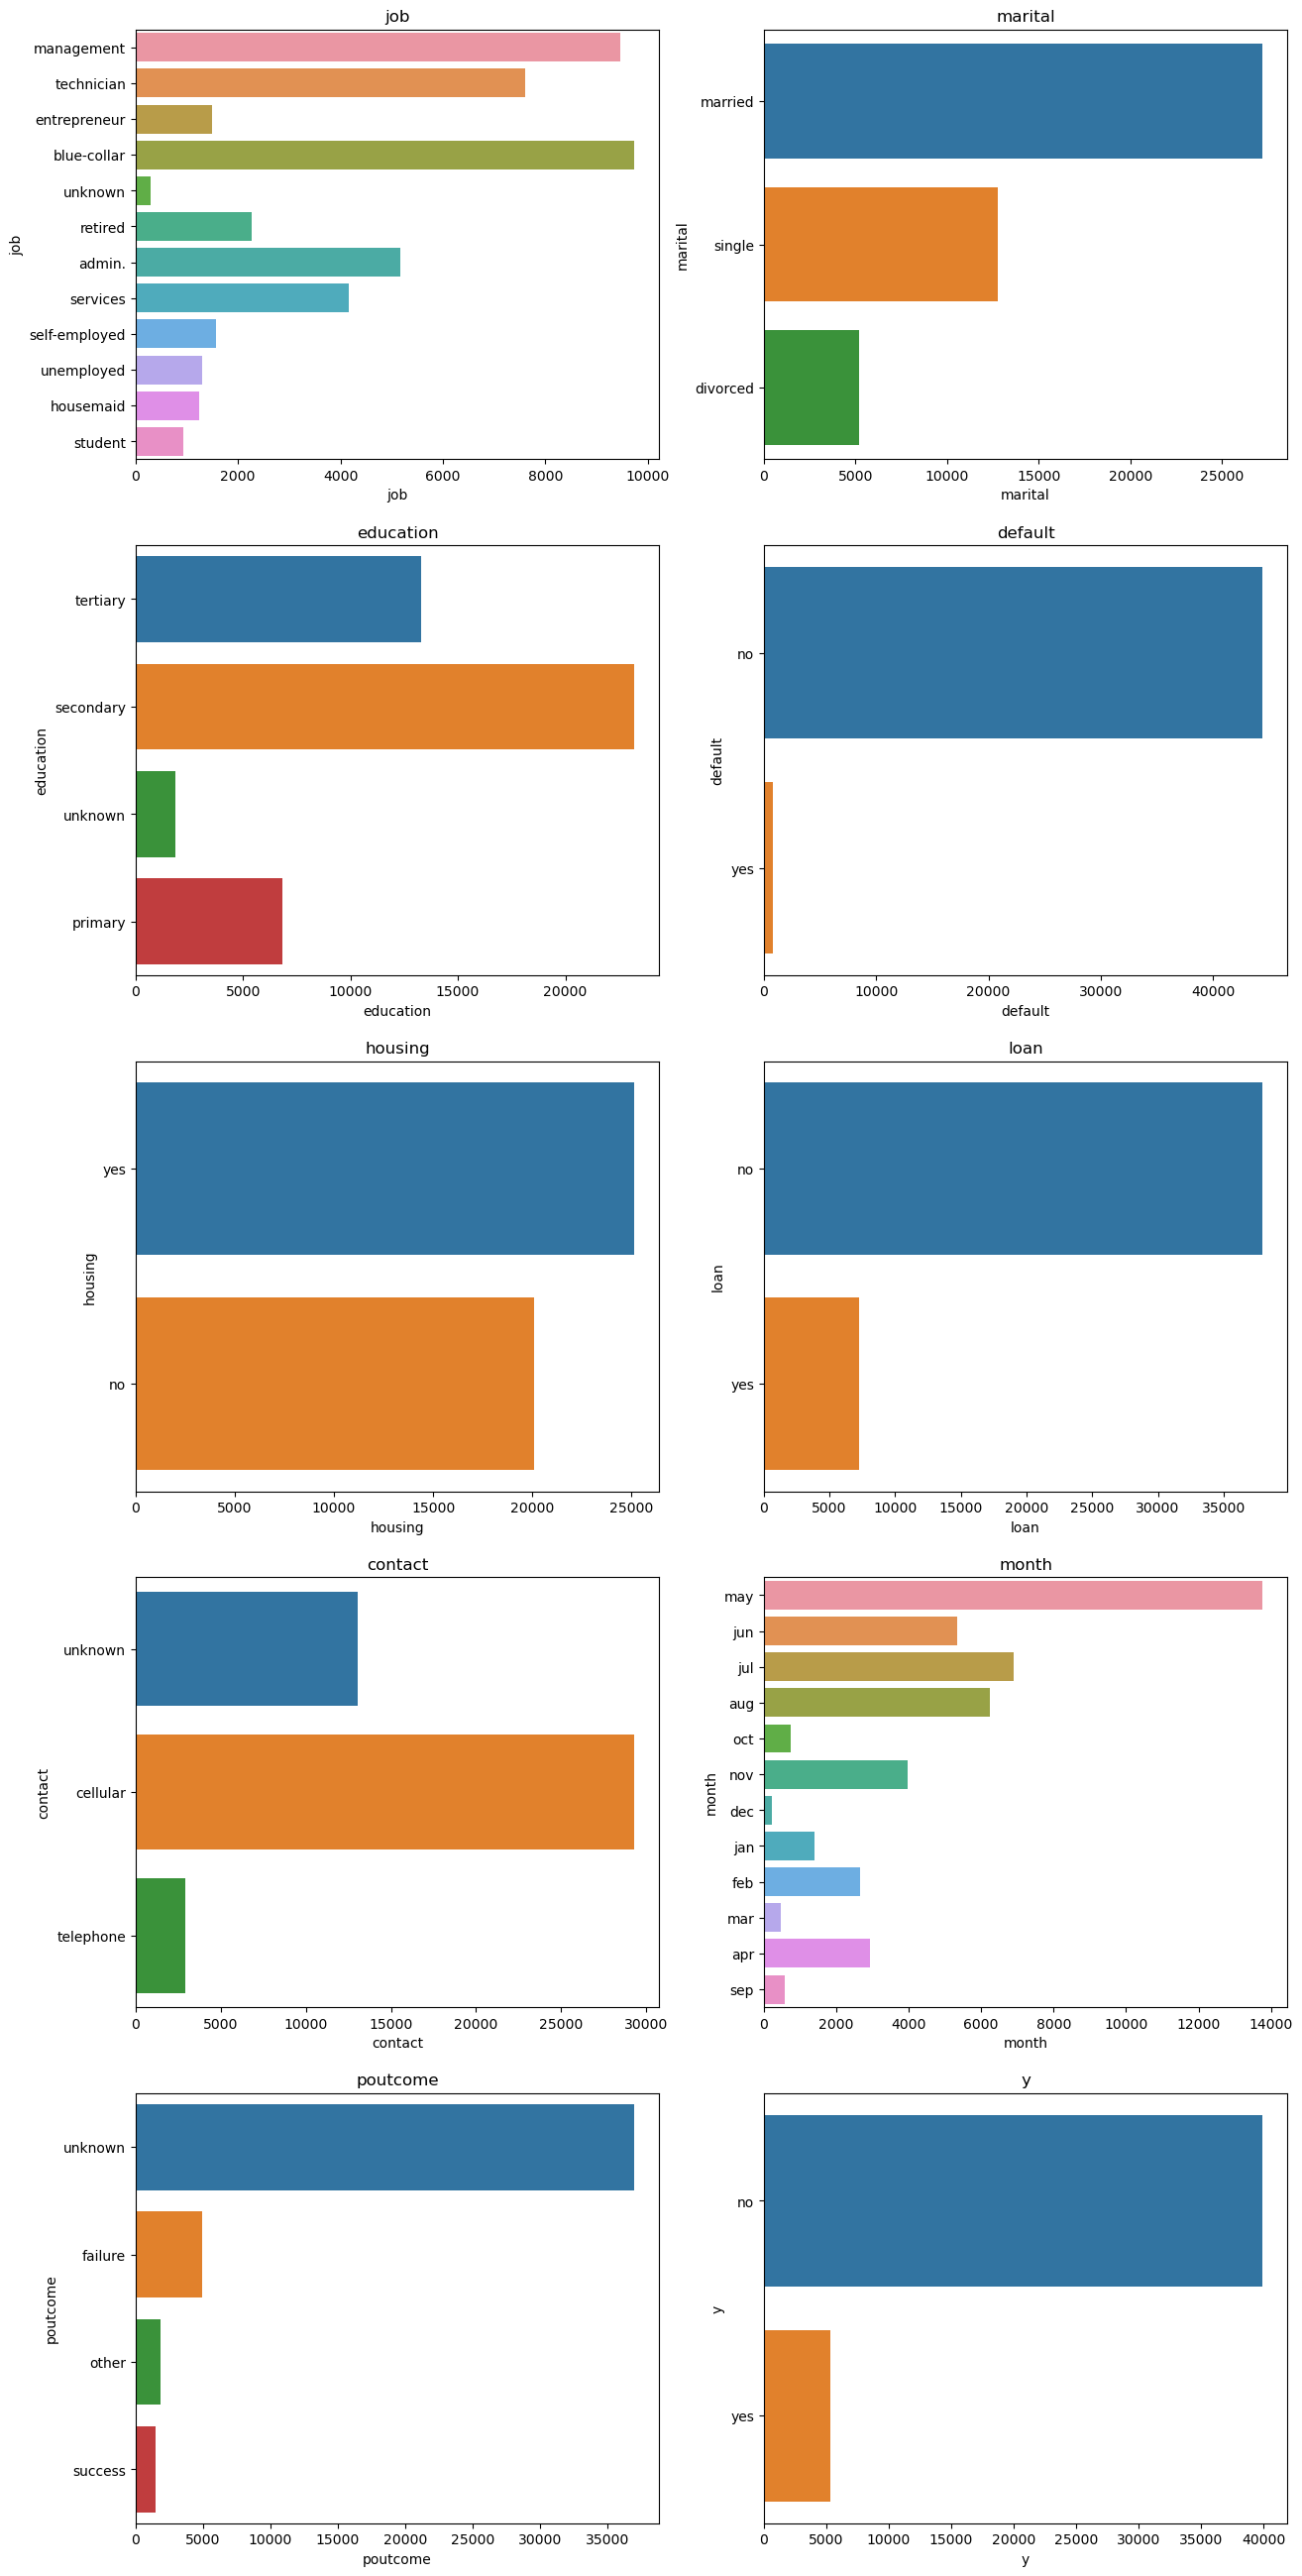

In [19]:
plt.figure(figsize=(15,80),facecolor='white')
plotnumber=1
for categorical_feature in categorical_features:
    ax=plt.subplot(12,2,plotnumber)
    sns.countplot(y=categorical_feature,data=dataset)
    plt.xlabel(categorical_feature)
    plt.title(categorical_feature)
    plotnumber+=1
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Dell\an

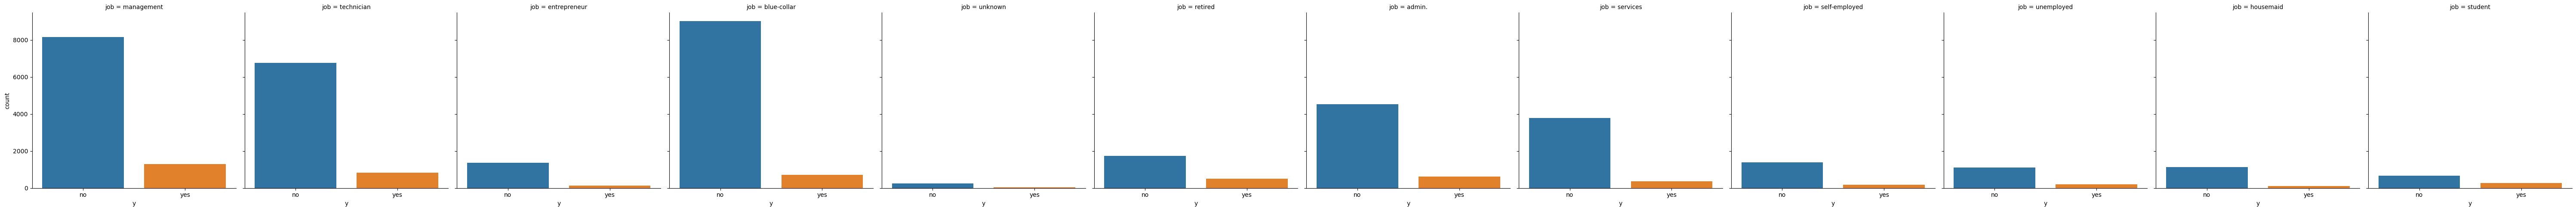

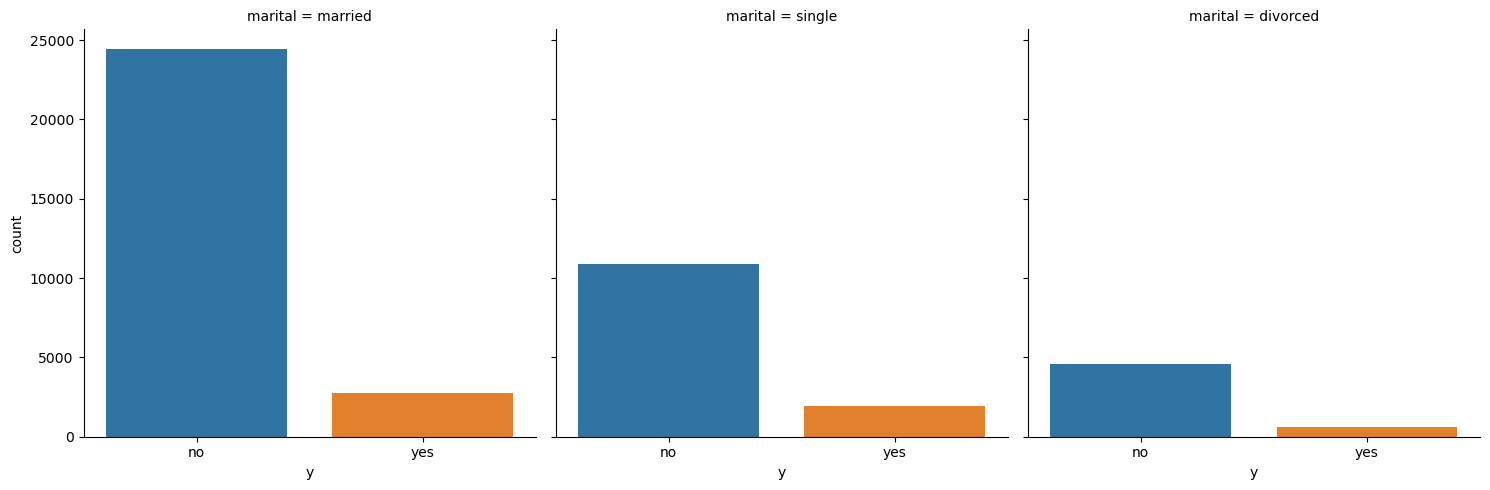

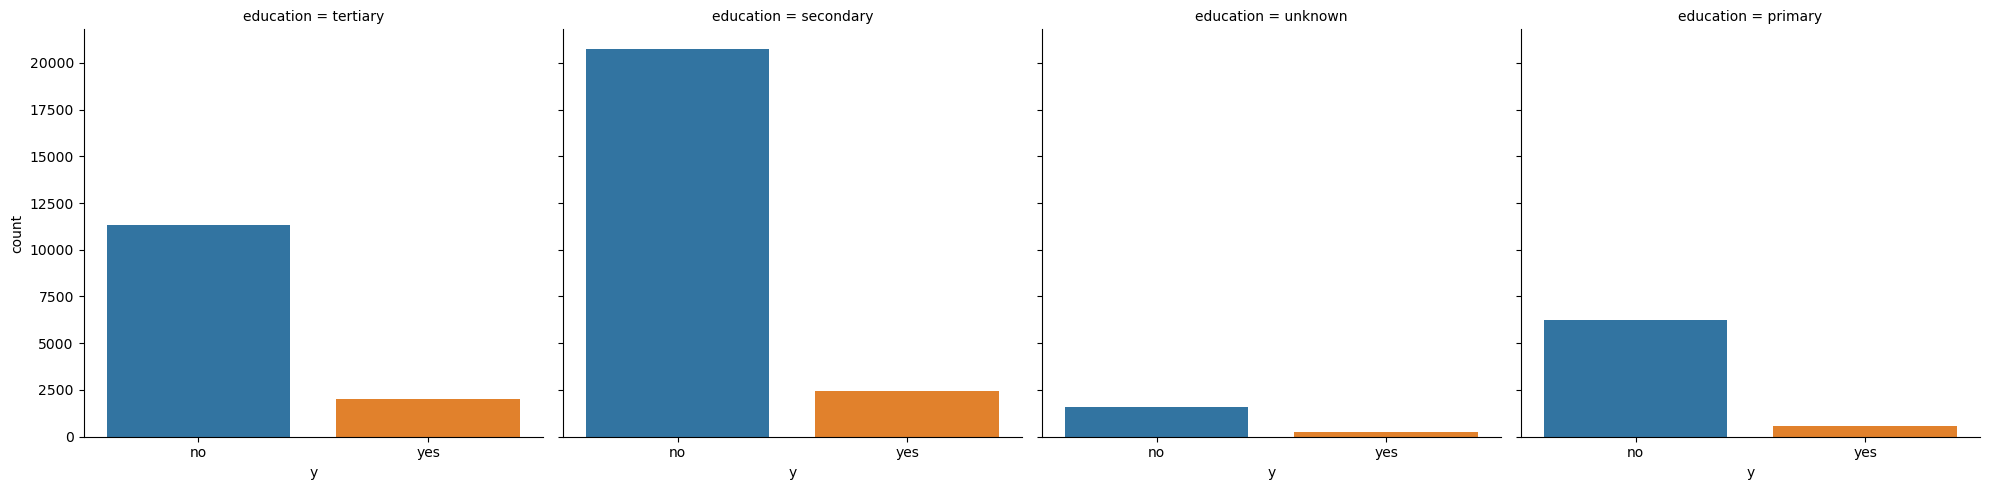

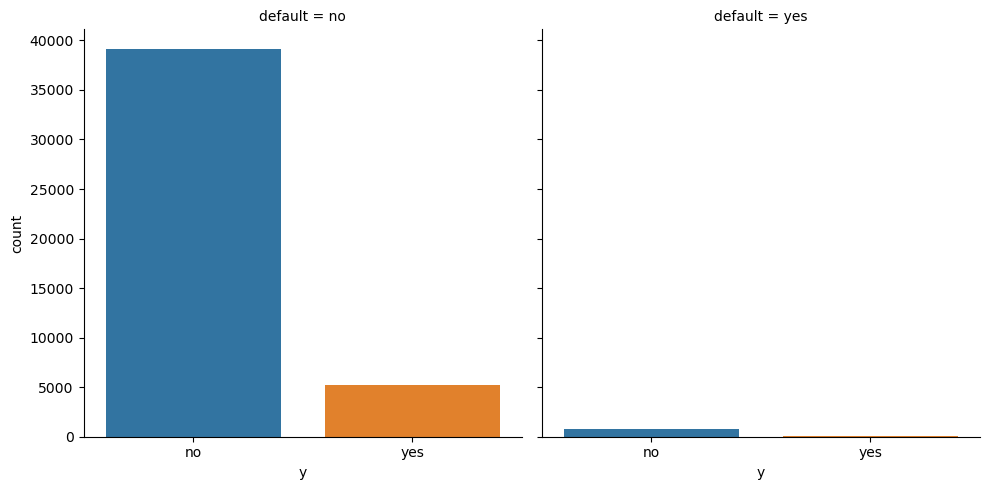

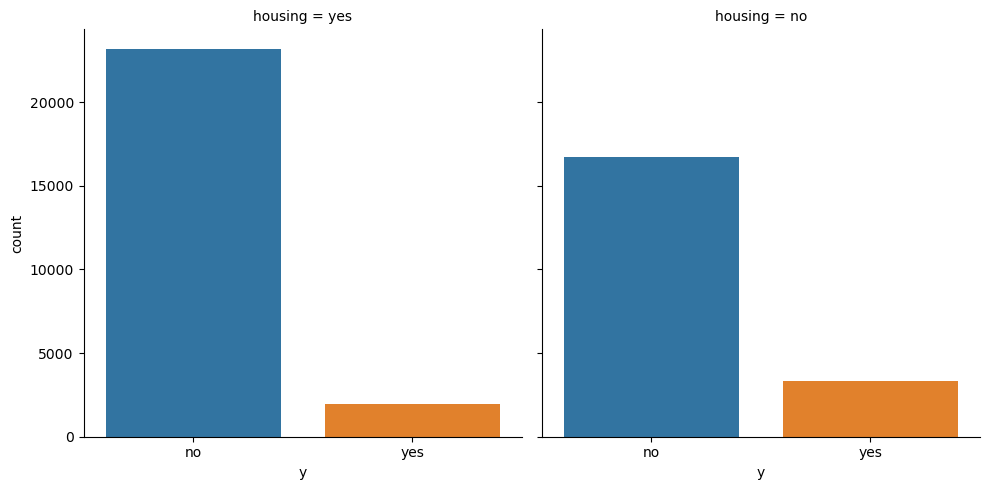

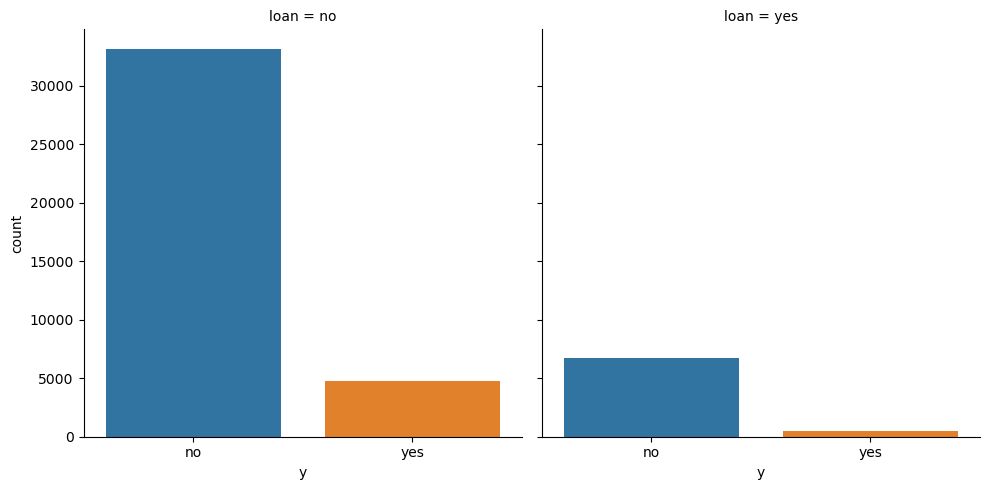

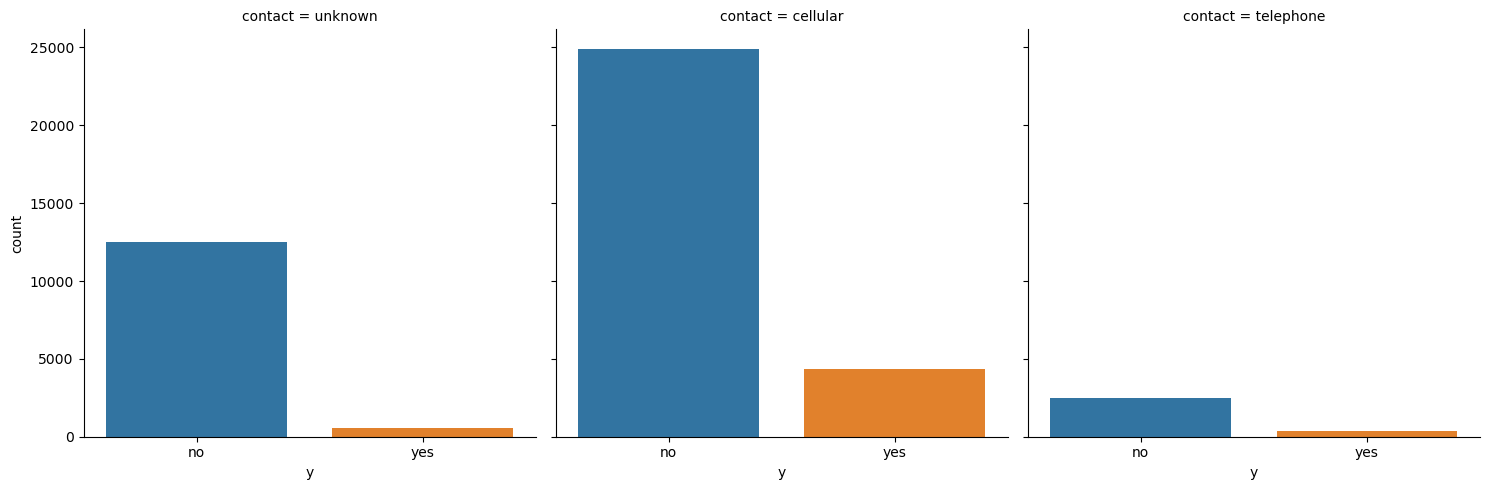

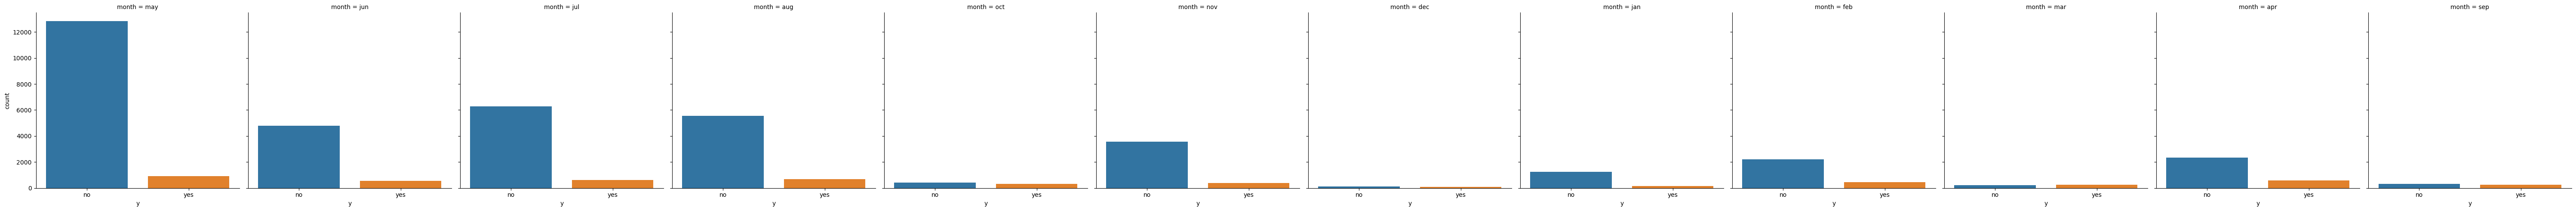

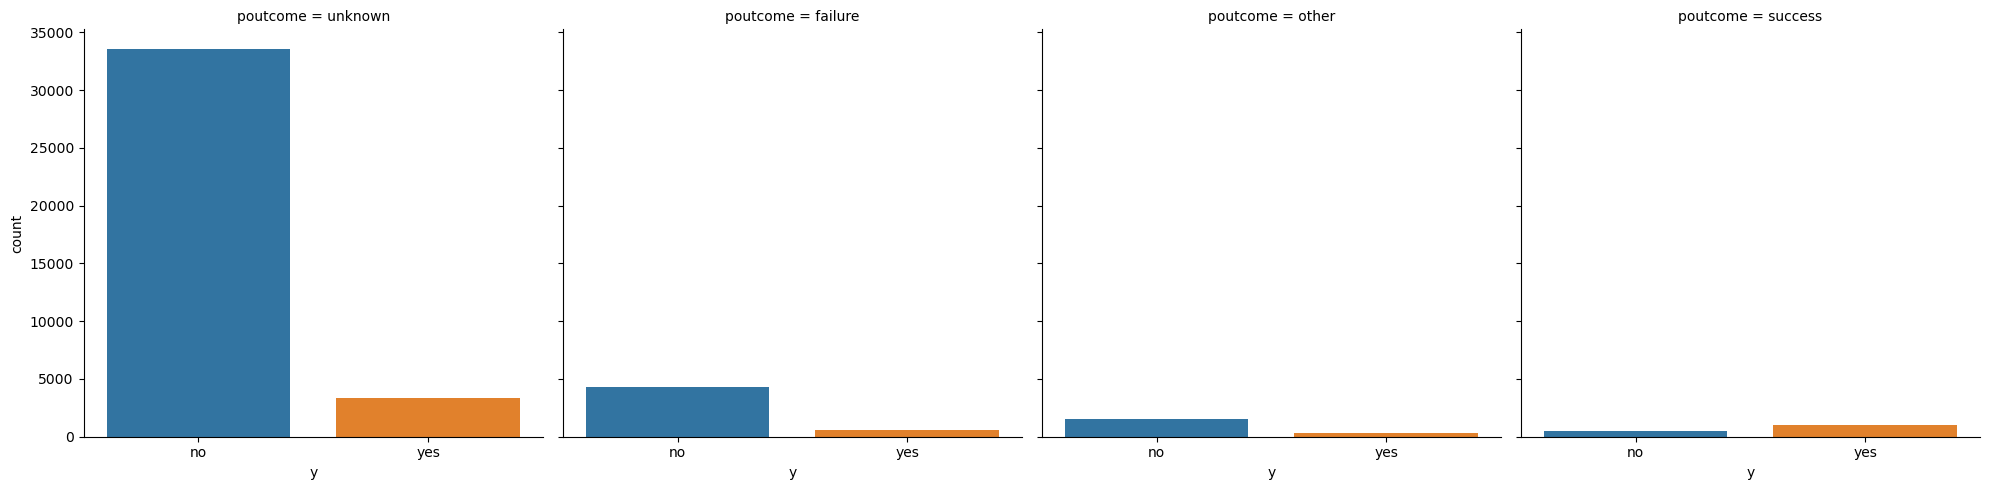

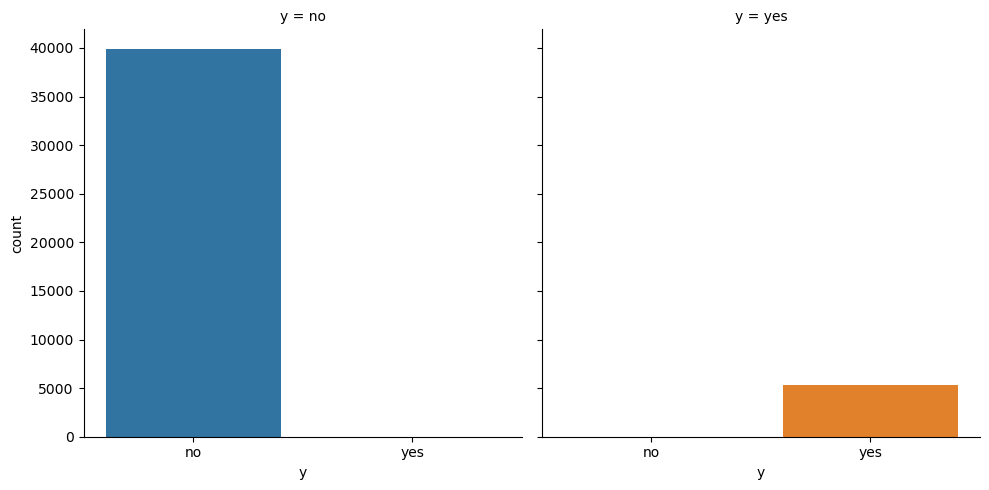

In [20]:
for categorical_feature in categorical_features:
    sns.catplot(x='y',col=categorical_feature,kind='count',data=dataset)
plt.show()

In [21]:
numerical_features=[feature for feature in dataset.columns if dataset[feature].dtypes!='O']
print("Number of numerical variable",len(numerical_features))
dataset[numerical_features].head()

Number of numerical variable 7


,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0


In [22]:
discrete_features=[feature for feature in numerical_features if len(dataset[feature].unique())<25]
print("Discretes:{}".format(len(discrete_features)))

Discretes:0


In [23]:
continuous_features=[feature for feature in numerical_features if feature not in discrete_features+['y']]
print("Continuous features {}".format(len(continuous_features)))

Continuous features 7


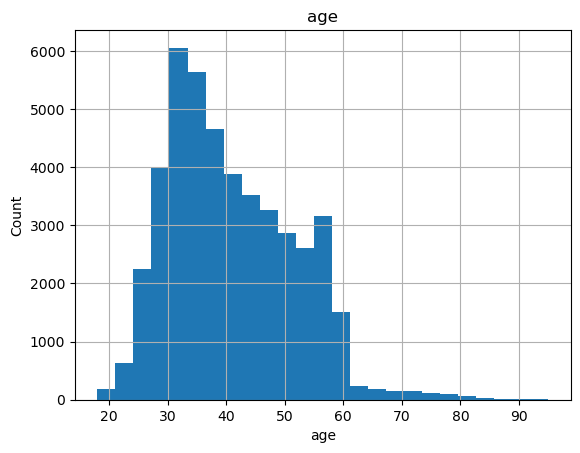

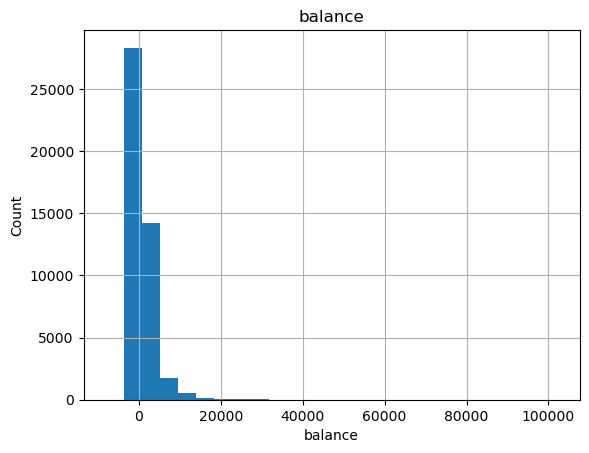

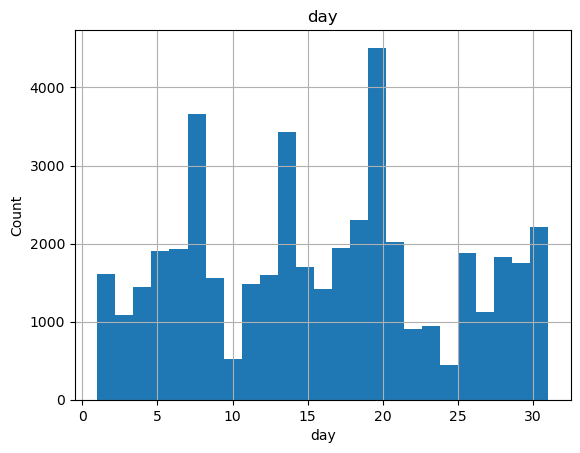

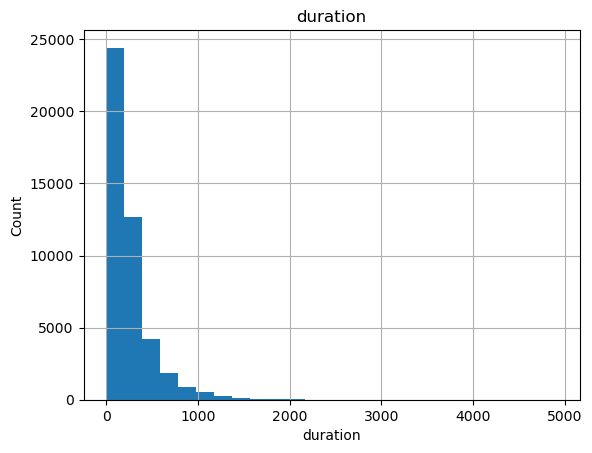

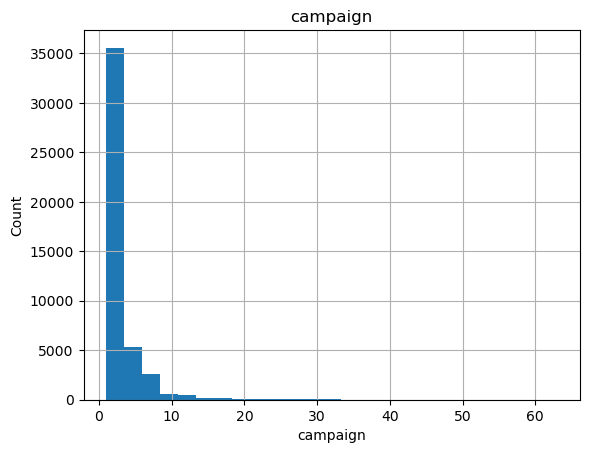

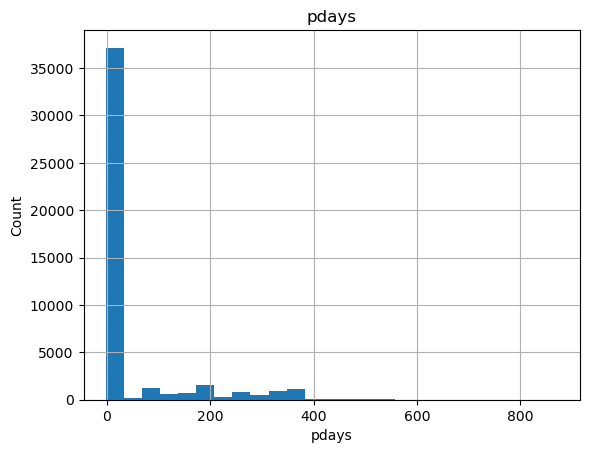

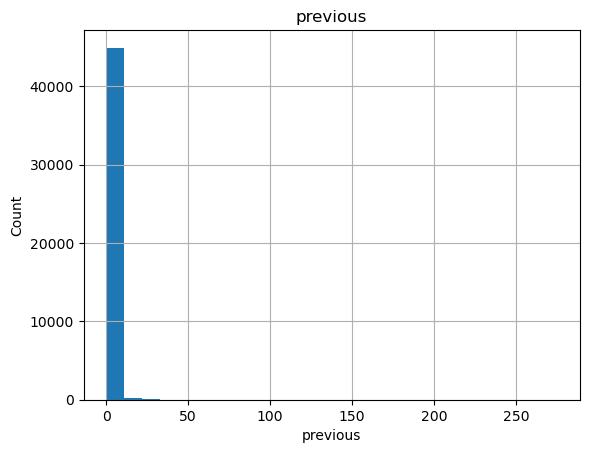

In [24]:
for feature in continuous_features:
    data=dataset.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(feature)
    plt.show()

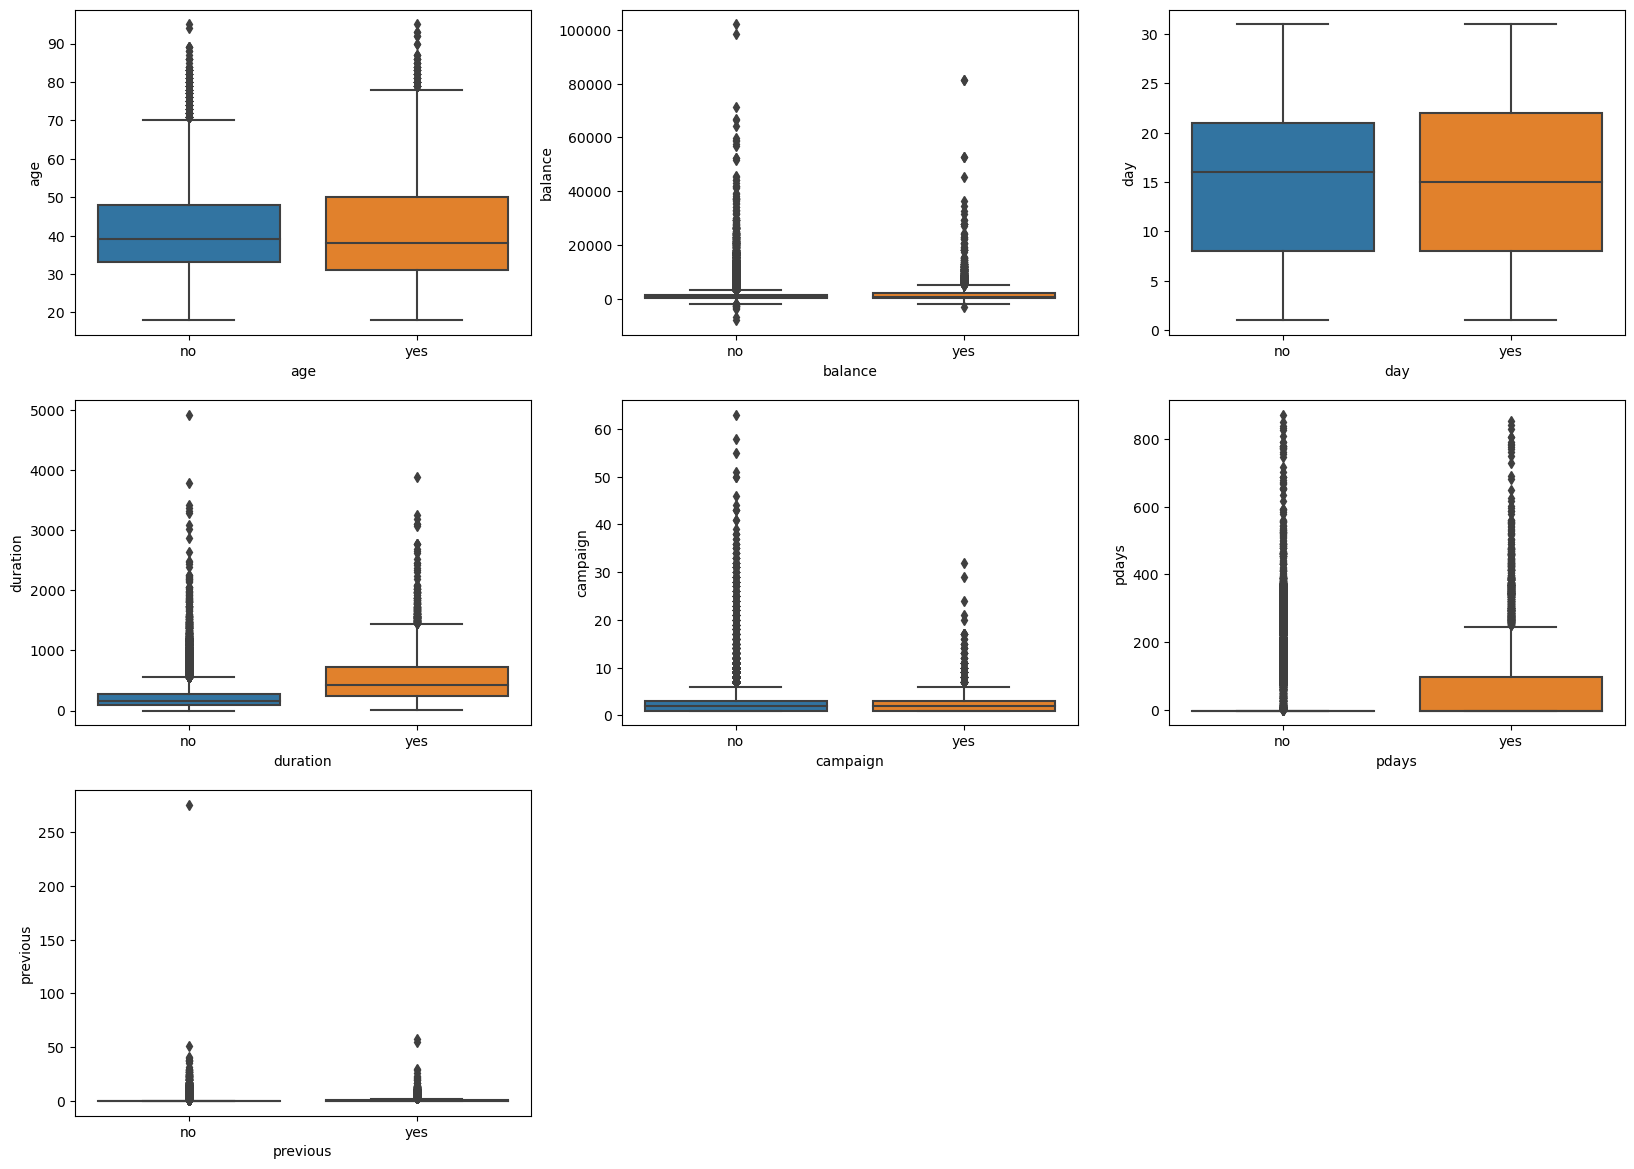

In [25]:
plt.figure(figsize=(20,60),facecolor='white')
plotnumber=1
for feature in continuous_features:
    ax=plt.subplot(12,3,plotnumber)
    sns.boxplot(x='y',y=dataset[feature],data=dataset)
    plt.xlabel(feature)
    plotnumber+=1
plt.show()

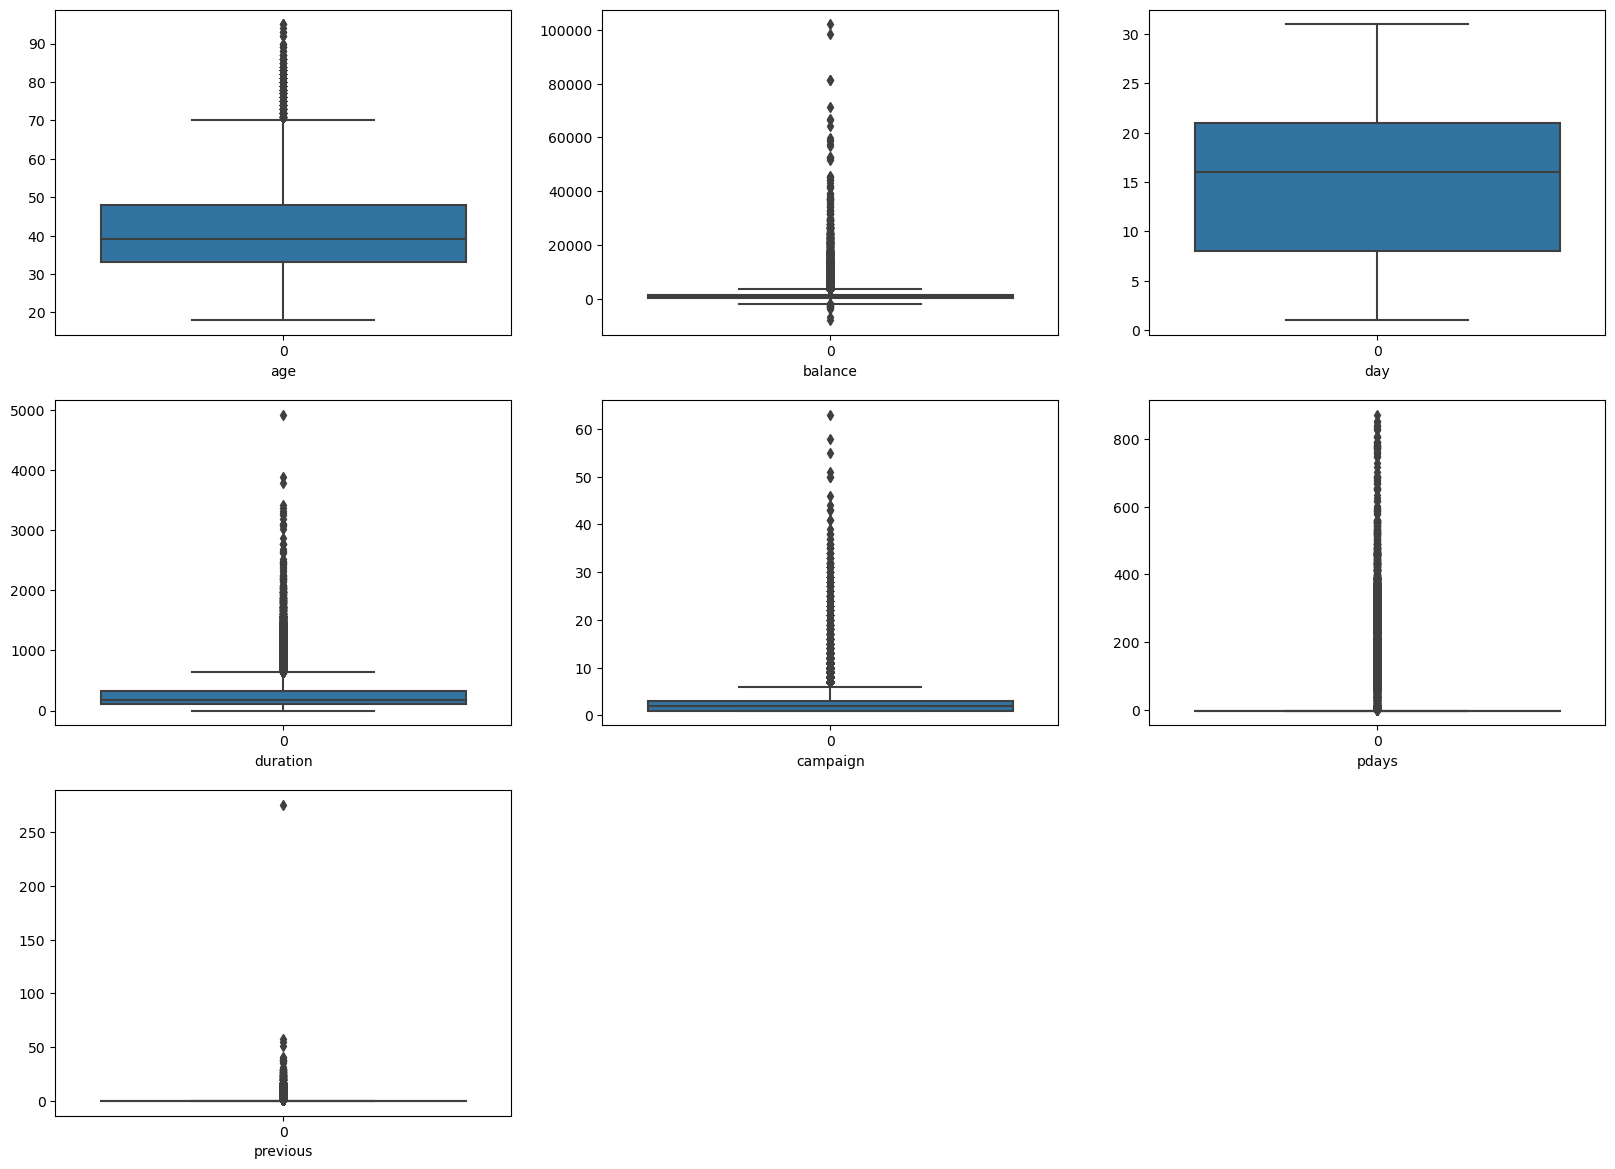

In [26]:
plt.figure(figsize=(20,60),facecolor='white')
plotnumber=1
for numerical_feature in numerical_features:
    ax=plt.subplot(12,3,plotnumber)
    sns.boxplot(dataset[numerical_feature])
    plt.xlabel(numerical_feature)
    plotnumber+=1
plt.show()

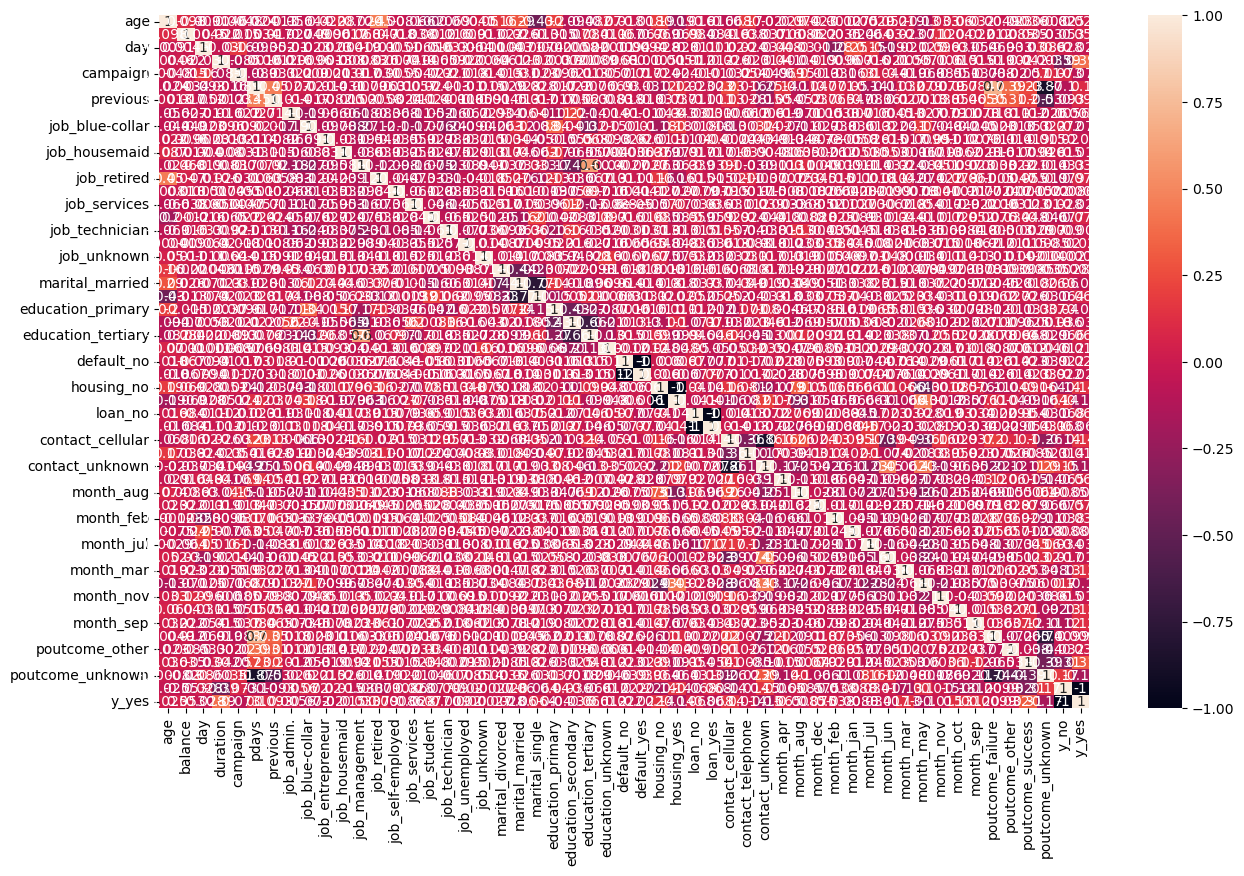

In [29]:
dataset_encoded = pd.get_dummies(dataset)  

cor_mat = dataset_encoded.corr()

plt.figure(figsize=(15, 9))
sns.heatmap(cor_mat, annot=True)
plt.show()

In [30]:
data.drop(['default'],axis=1,inplace=True)

In [31]:
data.groupby(['y','pdays']).size()

y    pdays
no   -1       33570
      1           9
      2          35
      3           1
      4           1
      5          11
      6           9
      7           7
      8          25
      9           9
      10          2
      12          7
      13          3
      14          8
      15          3
      17          3
      18          1
      19          2
      20          1
      21          3
      22          2
      24          2
      25          1
      26          1
      27          3
      28          8
      29          2
      30          1
      31          4
      32          1
      33          1
      34          1
      35          5
      36          3
      37          3
      38          1
      39          2
      40          4
      41          3
      42          3
      43          1
      44          2
      45          1
      46          2
      47          1
      48          2
      49          2
      50          6
      51          1
      53 

In [32]:
data.drop(['pdays'],axis=1,inplace=True)

In [34]:
from sklearn.preprocessing import StandardScaler

data=dataset.copy()

scaler=StandardScaler()
num_cols=['age','balance','day','campaign','pdays','previous']
data[num_cols]=scaler.fit_transform(data[num_cols])
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1.606965,management,married,tertiary,no,0.256419,yes,no,unknown,-1.298476,may,261,-0.569351,-0.411453,-0.25194,unknown,no
1,0.288529,technician,single,secondary,no,-0.437895,yes,no,unknown,-1.298476,may,151,-0.569351,-0.411453,-0.25194,unknown,no
2,-0.747384,entrepreneur,married,secondary,no,-0.446762,yes,yes,unknown,-1.298476,may,76,-0.569351,-0.411453,-0.25194,unknown,no
3,0.571051,blue-collar,married,unknown,no,0.047205,yes,no,unknown,-1.298476,may,92,-0.569351,-0.411453,-0.25194,unknown,no
4,-0.747384,unknown,single,unknown,no,-0.447091,no,no,unknown,-1.298476,may,198,-0.569351,-0.411453,-0.25194,unknown,no


In [38]:
from sklearn.preprocessing import OneHotEncoder




cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Create a copy of the dataset
data_encoded = dataset.copy()

encoder = OneHotEncoder(sparse=False)
df_encoded = pd.DataFrame(encoder.fit_transform(data_encoded[cat_cols]))
feature_names = encoder.get_feature_names_out(input_features=cat_cols)
df_encoded.columns = feature_names

data_encoded = data_encoded.drop(cat_cols, axis=1)
data_encoded = pd.concat([df_encoded, data_encoded], axis=1)
data_encoded['y'] = data_encoded['y'].apply(lambda x: 1 if x == 'yes' else 0)

print('Shape of the dataframe:', data_encoded.shape)
print(data_encoded.head())


Shape of the dataframe: (45211, 52)
   job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
0         0.0              0.0               0.0            0.0   
1         0.0              0.0               0.0            0.0   
2         0.0              0.0               1.0            0.0   
3         0.0              1.0               0.0            0.0   
4         0.0              0.0               0.0            0.0   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0             1.0          0.0                0.0           0.0          0.0   
1             0.0          0.0                0.0           0.0          0.0   
2             0.0          0.0                0.0           0.0          0.0   
3             0.0          0.0                0.0           0.0          0.0   
4             0.0          0.0                0.0           0.0          0.0   

   job_technician  job_unemployed  job_unknown  marital_divorced  \
0           

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [39]:
X=data.drop(['y'],axis=1)
y=data['y']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,shuffle=True,test_size=0.2,random_state=1)

print(X_train.shape,X_test.shape)

(36168, 16) (9043, 16)


In [47]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import pandas as pd


numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns


categorical_cols = X_train.select_dtypes(include=['object']).columns


numeric_imputer = SimpleImputer(strategy='mean')
X_train_numeric_imputed = numeric_imputer.fit_transform(X_train[numeric_cols])
X_test_numeric_imputed = numeric_imputer.transform(X_test[numeric_cols])


categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_categorical_imputed = categorical_imputer.fit_transform(X_train[categorical_cols])
X_test_categorical_imputed = categorical_imputer.transform(X_test[categorical_cols])


encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_train_categorical_encoded = encoder.fit_transform(X_train_categorical_imputed)
X_test_categorical_encoded = encoder.transform(X_test_categorical_imputed)


X_train_imputed = pd.concat([pd.DataFrame(X_train_numeric_imputed, columns=numeric_cols),
                             pd.DataFrame(X_train_categorical_encoded, columns=encoder.get_feature_names_out(categorical_cols))],
                            axis=1)
X_test_imputed = pd.concat([pd.DataFrame(X_test_numeric_imputed, columns=numeric_cols),
                            pd.DataFrame(X_test_categorical_encoded, columns=encoder.get_feature_names_out(categorical_cols))],
                           axis=1)


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


rfc = RandomForestClassifier(n_estimators=100, random_state=0)
rfc.fit(X_train_scaled, y_train)


y_pred = rfc.predict(X_test_scaled)


score = accuracy_score(y_test, y_pred)
print("Random forest model score:", score * 100)


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Random forest model score: 90.46776512219397
